## Approach Summary

- **Preprocessing**: Text normalization, token cleaning
- **Domain Classification**: Using `MoritzLaurer/deberta-v3-large-zeroshot-v1` model (Zero-shot classification)
- **Summarization**: Extractive summarization using `sshleifer/distilbart-cnn-12-6`
- **Keyword Extraction**: Using `KeyBERT` with `all-MiniLM-L6-v2`
- **Clustering**: Embedding + KMeans to group related topics
- **Tools Used**: pandas, sklearn, seaborn, matplotlib, transformers, KeyBERT, SentenceTransformer


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from wordcloud import WordCloud
import matplotlib.pyplot as plt
from transformers import pipeline

d:\KPMG_PWC_Analysis\KPMG_PwC_Insights\venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
df = pd.read_csv("output\output_analyzed_df.csv")


In [4]:
df

,title,link,content,date,source,clean_content,domain,summary,keywords,cluster
0,India CX Report'25: Commercial Real Estate\r\n...,https://kpmg.com/in/en/insights/2025/03/india-...,India CX Report'25: Commercial Real Estate clo...,2025-03-01 00:00:00,KPMG,india cx report commercial real estate close c...,Energy,Back industries aerospace defence space energ...,"['leasing', 'redevelopment', 'renovations', 'w...",2
1,India CX Report'25: Residential Real Estate\r\...,https://kpmg.com/in/en/insights/2025/03/india-...,India CX Report'25: Residential Real Estate cl...,2025-03-01 00:00:00,KPMG,india cx report residential real estate close ...,Energy,Back industries aerospace defence space energ...,"['residential', 'amenities', 'luxury', 'builde...",2
2,India CX Report'25: Real Estate\r\n \r\...,https://kpmg.com/in/en/insights/2025/03/india-...,India CX Report'25: Real Estate close contact_...,2025-03-01 00:00:00,KPMG,india cx report real estate close contactmail ...,Technology,Back industries aerospace defence space energ...,"['innovate', 'renewables', 'industries', 'expl...",2
3,India CX Report'25: Premium Hotels\r\n ...,https://kpmg.com/in/en/insights/2025/03/india-...,India CX Report'25: Premium Hotels close conta...,2025-03-01 00:00:00,KPMG,india cx report premium hotels close contactma...,Energy,Back industries aerospace defence space energ...,"['hotels', 'hotel', 'hotelchain', 'resorts', '...",2
4,India CX Report'25: Hotels\r\n \r\n ...,https://kpmg.com/in/en/insights/2025/03/india-...,India CX Report'25: Hotels close contact_mail ...,2025-03-01 00:00:00,KPMG,india cx report hotels close contactmail conta...,Technology,Back industries aerospace defence space energ...,"['hoteliers', 'hotels', 'hotel', 'establishmen...",2
5,India CX Report'25: Budget Hotels\r\n \...,https://kpmg.com/in/en/insights/2025/03/india-...,India CX Report'25: Budget Hotels close contac...,2025-03-01 00:00:00,KPMG,india cx report budget hotels close contactmai...,Energy,Back industries aerospace defence space energ...,"['hotels', 'hotel', 'hotelchain', 'facilities'...",2
6,India CX Report'25: Consumer Durables\r\n ...,https://kpmg.com/in/en/insights/2025/03/india-...,India CX Report'25: Consumer Durables close co...,2025-03-01 00:00:00,KPMG,india cx report consumer durables close contac...,Technology,Back industries aerospace defence space energ...,"['appliances', 'consumer', 'industries', 'rene...",2
7,India CX Report'25: Small Appliances\r\n ...,https://kpmg.com/in/en/insights/2025/03/india-...,India CX Report'25: Small Appliances close con...,2025-03-01 00:00:00,KPMG,india cx report small appliances close contact...,Technology,Back industries aerospace defence space energ...,"['appliances', 'appliance', 'electrical', 'ren...",2
8,India CX Report'25: Large Appliances\r\n ...,https://kpmg.com/in/en/insights/2025/03/india-...,India CX Report'25: Large Appliances close con...,2025-03-01 00:00:00,KPMG,india cx report large appliances close contact...,Technology,Back industries aerospace defence space energ...,"['appliances', 'appliance', 'electrical', 'ren...",2
9,Evolving third party landscape in India's medi...,https://kpmg.com/in/en/insights/2025/03/evolvi...,Evolving third party landscape in India's medi...,2025-03-01 00:00:00,KPMG,evolving third party landscape indias media en...,Technology,Back industries aerospace defence space energ...,"['sector', 'emerging', 'indias', 'industries',...",2


In [5]:
print(df.columns)      # See available columns

Index(['title', 'link', 'content', 'date', 'source', 'clean_content', 'domain',
       'summary', 'keywords', 'cluster'],
      dtype='object')


In [6]:
print(df.info())       # Check data types and non-null counts

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 34 entries, 0 to 33
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   title          34 non-null     object
 1   link           34 non-null     object
 2   content        34 non-null     object
 3   date           34 non-null     object
 4   source         34 non-null     object
 5   clean_content  34 non-null     object
 6   domain         34 non-null     object
 7   summary        34 non-null     object
 8   keywords       34 non-null     object
 9   cluster        34 non-null     int64 
dtypes: int64(1), object(9)
memory usage: 2.8+ KB
None


In [7]:
df.head(5)

,title,link,content,date,source,clean_content,domain,summary,keywords,cluster
0,India CX Report'25: Commercial Real Estate\r\n...,https://kpmg.com/in/en/insights/2025/03/india-...,India CX Report'25: Commercial Real Estate clo...,2025-03-01 00:00:00,KPMG,india cx report commercial real estate close c...,Energy,Back industries aerospace defence space energ...,"['leasing', 'redevelopment', 'renovations', 'w...",2
1,India CX Report'25: Residential Real Estate\r\...,https://kpmg.com/in/en/insights/2025/03/india-...,India CX Report'25: Residential Real Estate cl...,2025-03-01 00:00:00,KPMG,india cx report residential real estate close ...,Energy,Back industries aerospace defence space energ...,"['residential', 'amenities', 'luxury', 'builde...",2
2,India CX Report'25: Real Estate\r\n \r\...,https://kpmg.com/in/en/insights/2025/03/india-...,India CX Report'25: Real Estate close contact_...,2025-03-01 00:00:00,KPMG,india cx report real estate close contactmail ...,Technology,Back industries aerospace defence space energ...,"['innovate', 'renewables', 'industries', 'expl...",2
3,India CX Report'25: Premium Hotels\r\n ...,https://kpmg.com/in/en/insights/2025/03/india-...,India CX Report'25: Premium Hotels close conta...,2025-03-01 00:00:00,KPMG,india cx report premium hotels close contactma...,Energy,Back industries aerospace defence space energ...,"['hotels', 'hotel', 'hotelchain', 'resorts', '...",2
4,India CX Report'25: Hotels\r\n \r\n ...,https://kpmg.com/in/en/insights/2025/03/india-...,India CX Report'25: Hotels close contact_mail ...,2025-03-01 00:00:00,KPMG,india cx report hotels close contactmail conta...,Technology,Back industries aerospace defence space energ...,"['hoteliers', 'hotels', 'hotel', 'establishmen...",2


In [8]:
df['source'].value_counts()


source
KPMG    26
PWC      8
Name: count, dtype: int64

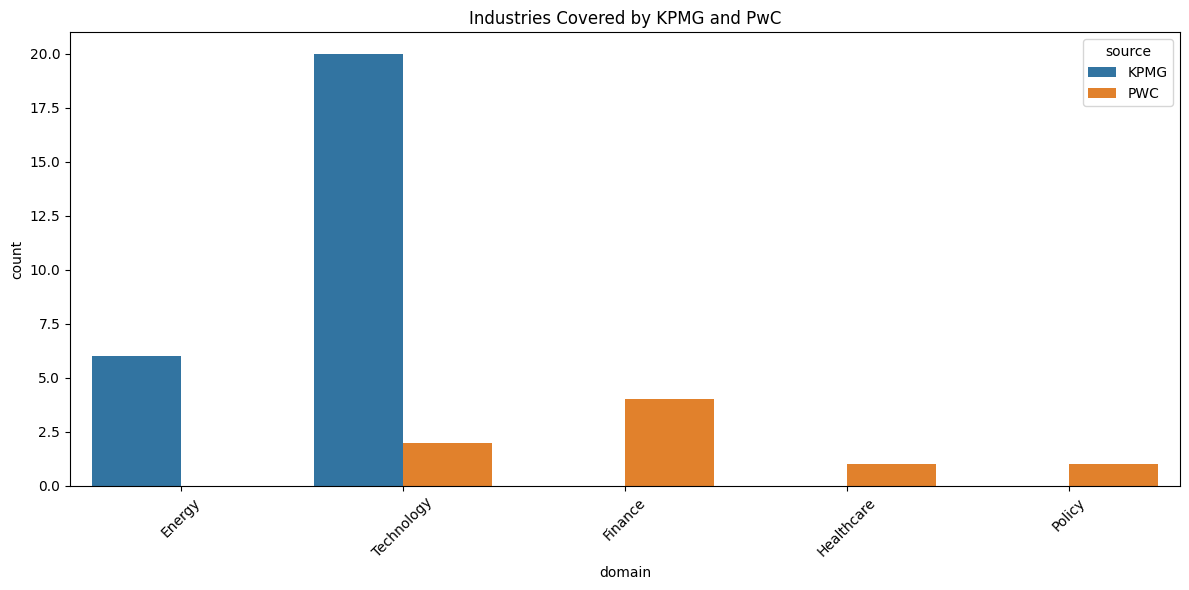

In [9]:
# Plot industries covered
plt.figure(figsize=(12, 6))
sns.countplot(data=df, x='domain', hue='source')
plt.title("Industries Covered by KPMG and PwC")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [10]:
kpmg_keywords = df[df['source'] == 'KPMG']['keywords'].explode().dropna()
pwc_keywords = df[df['source'] == 'PWC']['keywords'].explode().dropna()

In [11]:
def plot_wordcloud(keywords, title):
    wordcloud = WordCloud(width=800, height=400, background_color='white').generate(' '.join(keywords))
    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation="bilinear")
    plt.axis("off")
    plt.title(title)
    plt.show()


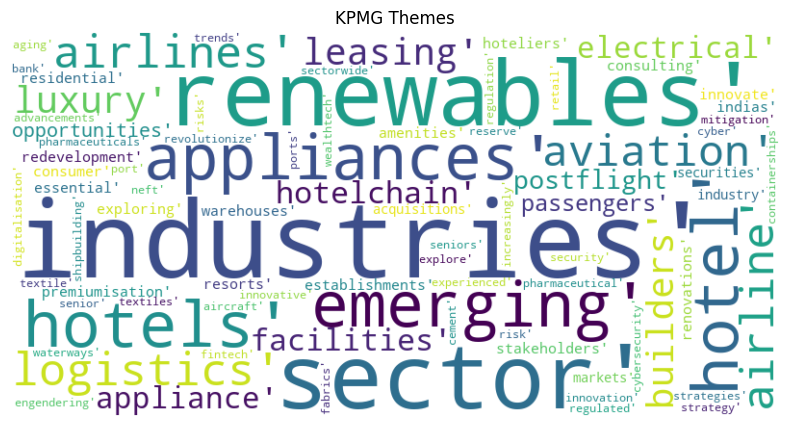

In [12]:
# Use with keyword lists
plot_wordcloud(kpmg_keywords, "KPMG Themes")

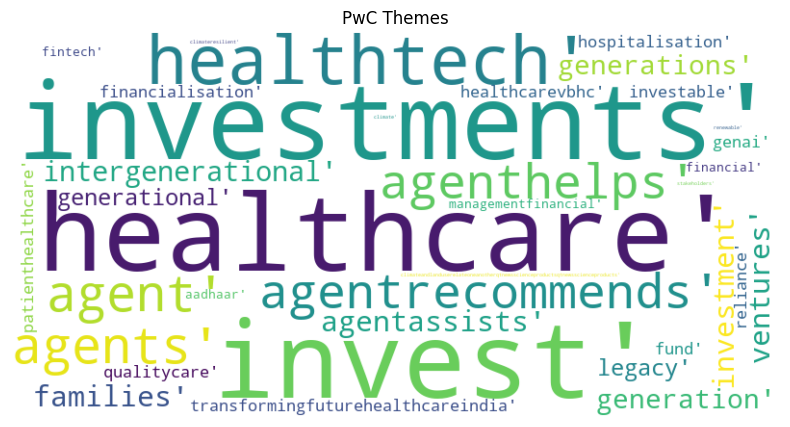

In [13]:
plot_wordcloud(pwc_keywords, "PwC Themes")

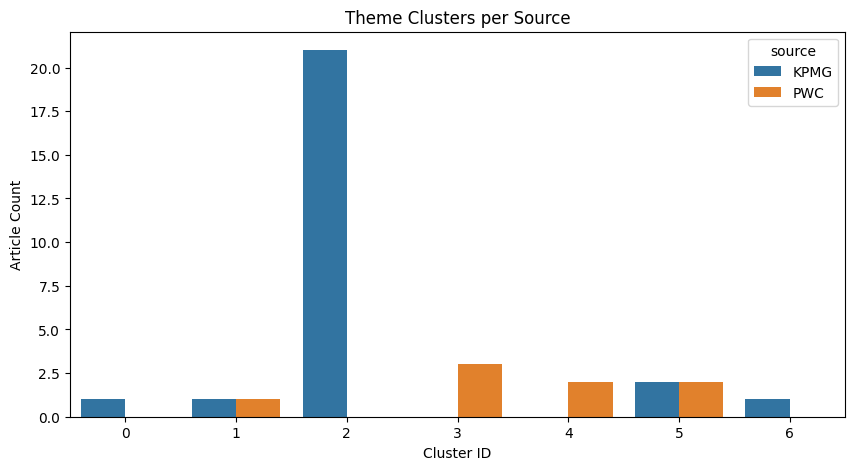

In [14]:
# Cluster distribution
plt.figure(figsize=(10, 5))
sns.countplot(data=df, x='cluster', hue='source')
plt.title("Theme Clusters per Source")
plt.xlabel("Cluster ID")
plt.ylabel("Article Count")
plt.show()


In [16]:
# Filter KPMG articles
kpmg_df = df[df['source'].str.upper() == 'KPMG'].copy()

# Filter PwC articles
pwc_df = df[df['source'].str.upper() == 'PWC'].copy()


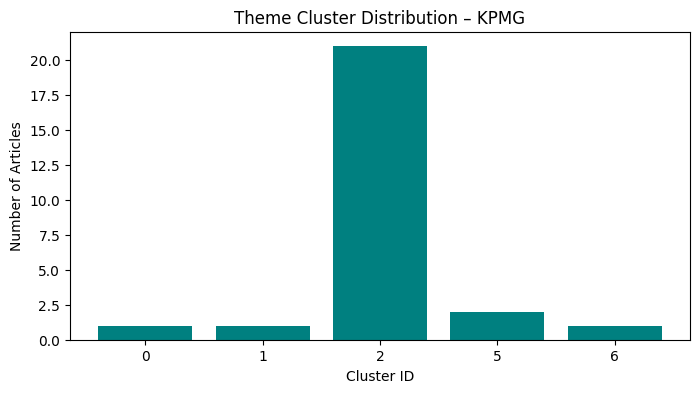

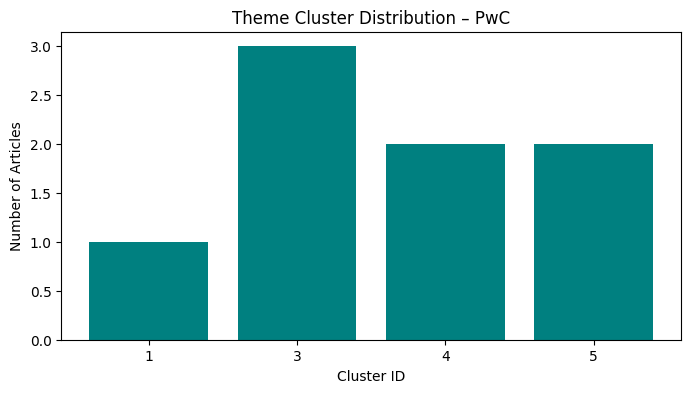

In [17]:
def plot_cluster_distribution(df, source_name):
    cluster_counts = df['cluster'].value_counts().sort_index()
    plt.figure(figsize=(8, 4))
    plt.bar(cluster_counts.index.astype(str), cluster_counts.values, color='teal')
    plt.xlabel("Cluster ID")
    plt.ylabel("Number of Articles")
    plt.title(f"Theme Cluster Distribution – {source_name}")
    plt.show()

plot_cluster_distribution(kpmg_df, "KPMG")
plot_cluster_distribution(pwc_df, "PwC")


## Comparative Insights

- **KPMG Focus**: [e.g., Real Estate, Policy, Sustainability]
- **PwC Focus**: [e.g., Finance, Technology, Healthcare]

**Cluster-Based Differences**:
- Cluster 0: Mostly KPMG -> Focuses on X
- Cluster 1: Mixed -> Common ground on Y
- Cluster 2: Mostly PwC -> Focuses on Z

**Keyword Differences**:
- KPMG uses keywords like “sustainability”, “regulatory”, “risk”
- PwC emphasizes “growth”, “fintech”, “AI”

### **KPMG – Key Themes and Insights**
**Top keywords: industries, renewables, sector, logistics, aviation, hotels, luxury, builders**

📝 Insights:

- **Industry Diversification:** KPMG's content covers a wide array of industries including aviation, logistics, hospitality, and consumer appliances, highlighting a strong focus on cross-sectoral insights.

- **Focus on Renewable Energy**: Keywords like renewables, energy, and emerging suggest KPMG is emphasizing the transition towards green and sustainable energy solutions.

- **Real Estate & Hospitality Emphasis:** Several articles delve into residential/commercial real estate and luxury hotel chains, reflecting interest in property development trends and customer experiences.

- **Aviation & Logistics Innovation:** Repeated mentions of airlines, aviation, and logistics point to KPMG’s attention on infrastructure and mobility challenges or transformation.


### **PwC – Key Themes and Insights**
**Top keywords: investments, healthcare, healthtech, ventures, families, generation, agent**

📝 Insights:

- **Investment-Centric Perspective:** Terms like investments, invest, and ventures show PwC’s reports are focused on investment strategies and portfolio diversification.

- **Healthcare & Healthtech Focus:** There's a clear interest in the growth of the healthcare industry, especially tech-driven healthcare solutions (healthtech).

- **Wealth Transfer & Generational Planning:** PwC emphasizes topics such as intergenerational wealth, planning for families, and financial literacy across generations.

- **Advisory & Personalization:** Keywords related to agent, agentrecommends, and agentassists indicate a trend toward personalized advisory or tech-assisted consulting models.